In [30]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [31]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [32]:
trades = get_btc_trades_extended()
print(f"Got {len(trades)} trades")

print(trades.dtypes)
trades.head()

Got 5000 trades
trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-20 04:23:18.816857+00:00,1021369104,buy,4.000000e-08,76729.83
2026-05-20 04:23:19.344312+00:00,1021369105,sell,4.857000e-05,76729.88
2026-05-20 04:23:19.477619+00:00,1021369106,buy,4.000000e-08,76729.87
2026-05-20 04:23:19.783803+00:00,1021369107,buy,1.200000e-07,76729.87
2026-05-20 04:23:20.065305+00:00,1021369108,buy,5.000000e-08,76729.87


In [33]:
book = OrderBook()
mm = MarketMaker(starting_wealth=100000, order_book=book)
sim = Simulator(mm=mm, book=book, df=trades, window=20)

mm.start_session()
sim.run()

In [34]:
print(f"Total buy trades: {len(trades[trades['side'] == 'buy'])}")
print(f"Total sell trades: {len(trades[trades['side'] == 'sell'])}")
print(f"Starting price: {trades['price'].iloc[0]}")
print(f"Ending price: {trades['price'].iloc[-1]}")
print(f"Price change: {trades['price'].iloc[-1] - trades['price'].iloc[0]:.2f}")

Total buy trades: 3384
Total sell trades: 1616
Starting price: 76729.83
Ending price: 76719.65
Price change: -10.18


In [35]:
results = sim.get_results()
results.tail(15)

,Mid_Price,Reservation_Price,Bid,Ask,Position,PnL,Spread
Time,,,,,,,
4985,76706.8890,76706.8890,76704.957166,76708.820834,0.265876,6.685831,3.863668
4986,76707.8720,76707.8720,76705.940166,76709.803834,0.265876,6.947187,3.863668
4987,76708.8545,76708.8545,76706.922666,76710.786334,0.265876,7.208411,3.863668
4988,76709.8370,76709.8370,76707.905166,76711.768834,0.265876,7.469634,3.863668
4989,76710.8200,76710.8200,76708.888166,76712.751834,0.265876,7.730990,3.863668
4990,76711.8025,76711.8025,76709.870349,76713.734651,0.255876,8.070687,3.864303
4991,76712.7850,76712.7850,76710.884536,76714.685464,0.245876,8.390735,3.800928
4992,76713.7675,76713.7675,76711.888335,76715.646665,0.245876,8.632308,3.758330
4993,76714.7505,76714.7505,76712.871335,76716.629665,0.245876,8.874004,3.758330


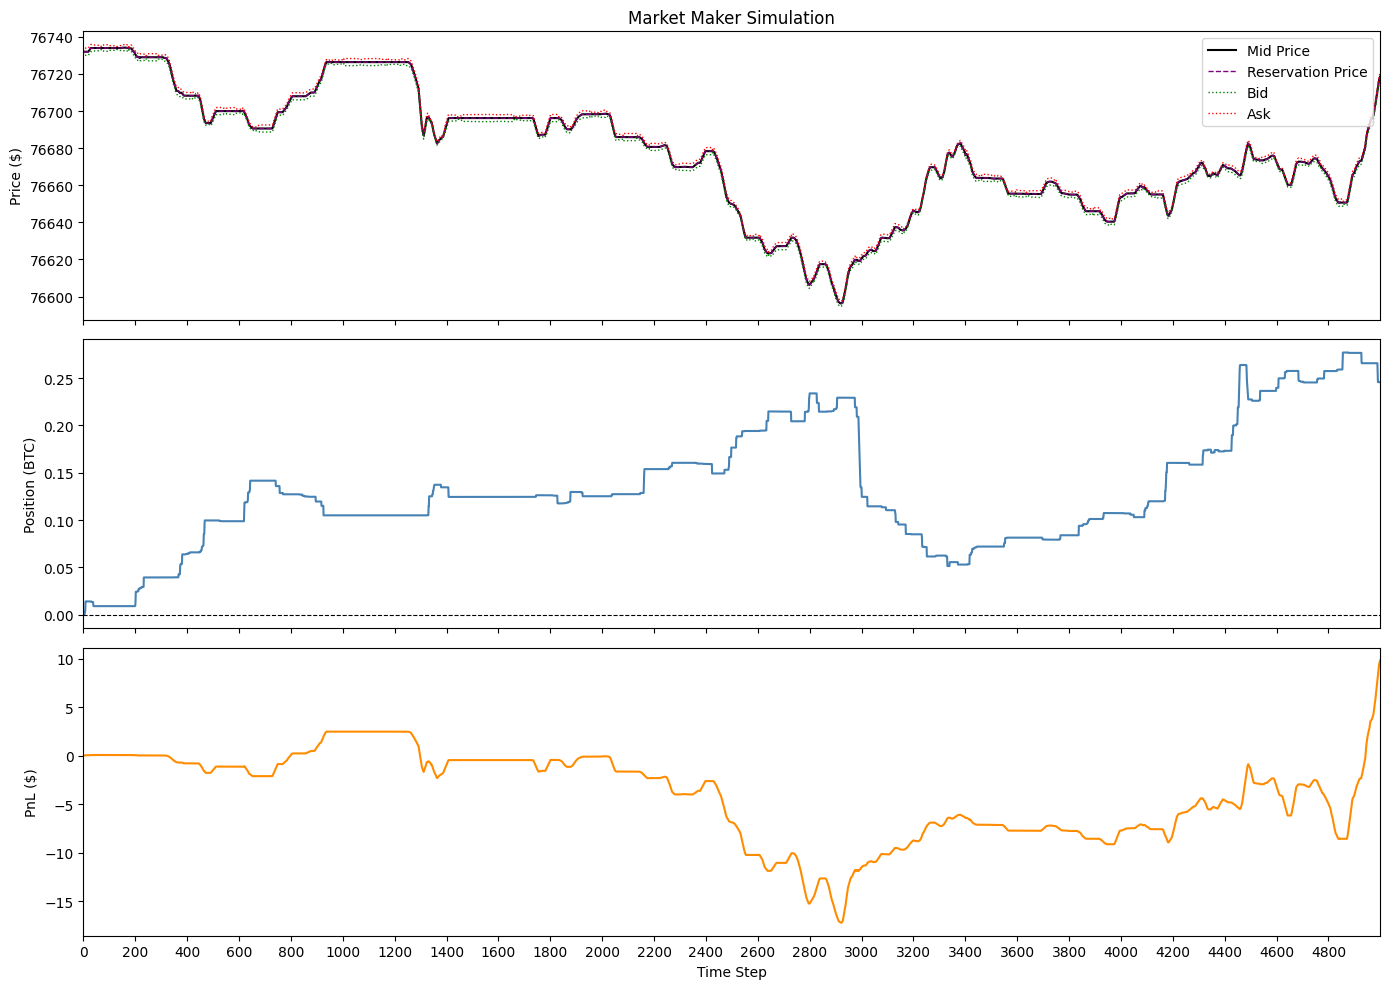

In [36]:
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(results.index, results['Mid_Price'], label='Mid Price', color='black', linewidth=1.5)
ax1.plot(results.index, results['Reservation_Price'], label='Reservation Price', color='purple', linewidth=1, linestyle='--')
ax1.plot(results.index, results['Bid'], label='Bid', color='green', linewidth=1, linestyle=':')
ax1.plot(results.index, results['Ask'], label='Ask', color='red', linewidth=1, linestyle=':')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper right')
ax1.set_title('Market Maker Simulation')
ax1.set_xlim(results.index[0], results.index[-1])

ax2.plot(results.index, results['Position'], color='steelblue', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Position (BTC)')

ax3.plot(results.index, results['PnL'], color='darkorange', linewidth=1.5)
ax3.set_ylabel('PnL ($)')
ax3.set_xlabel('Time Step')
ax3.xaxis.set_major_locator(MultipleLocator(200))


plt.tight_layout()
plt.show()

Consistently ending with position around +0.2.

Market dominated by aggressive buyers and price rises over the sample.

Buyers keep hitting ask -> strategy sells
Gamma kicks in -> quotes rise
Ask and bid moves higher -> more sellers hit bids and less buyers hit ask

Dynamic gamma works and overcorrects, so strategy doesn't go infinitely short

In [ ]:
results.to_csv('../data/simulation_results.csv', index=